# **3. Análisis Exploratorio de Datos**

**Estructura del dataset:**
```
brisc2025/
└── segmentation_task/
    ├── train/
    │   ├── images/
    │   └── masks/
    └── test/
        ├── images/
        └── masks/
```

**Fuente:** {cite}`fateh2026brisc`. BRISC: Brain Image Segmentation Challenge Dataset. *Scientific Data*, Nature.

## Configuración e Importaciones

In [1]:
import os
import re
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configuración de visualización
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH   = Path('brisc2025/segmentation_task')
PARTICIONES = ['train', 'test']

COLORES_PARTICION = {
    'train': '#2196F3',
    'test':  '#E53935'
}

print(f'Directorio base: {BASE_PATH}')
for p in PARTICIONES:
    dir_img = BASE_PATH / p / 'images'
    dir_msk = BASE_PATH / p / 'masks'
    print(f'  {p}/images : existe={dir_img.exists()}')
    print(f'  {p}/masks  : existe={dir_msk.exists()}')

Directorio base: brisc2025\segmentation_task
  train/images : existe=True
  train/masks  : existe=True
  test/images : existe=True
  test/masks  : existe=True


---
## 1. Carga y Visualización Inicial

Antes de cualquier análisis cuantitativo conviene ver el material con el que se trabaja. Se muestra una imagen representativa de cada partición junto a su máscara de segmentación, para tener intuición sobre la apariencia visual de las imágenes MRI y de cómo lucen las regiones tumorales anotadas.

Las máscaras son binarias: los píxeles blancos (255) corresponden a la región tumoral y los píxeles negros (0) al tejido sano y al fondo. Esta anotación es el ground truth que el modelo deberá aprender a reproducir píxel a píxel.

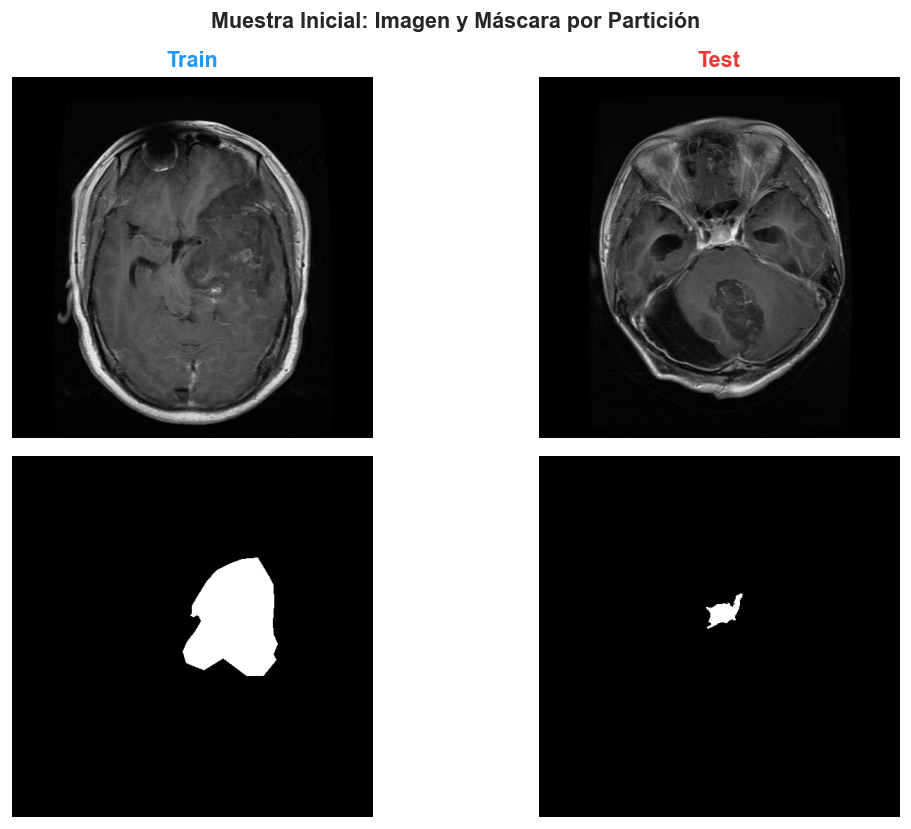

Figura guardada: eda_01_visualizacion_inicial.png


In [3]:
def extraer_numero(nombre_archivo):
    """Extrae el primer número del nombre de un archivo para ordenar correctamente."""
    coincidencia = re.search(r'\d+', os.path.basename(str(nombre_archivo)))
    return int(coincidencia.group()) if coincidencia else float('inf')

fig, axes = plt.subplots(2, len(PARTICIONES), figsize=(10, 7))
fig.suptitle('Muestra Inicial: Imagen y Máscara por Partición', fontsize=13, fontweight='bold')

for i, particion in enumerate(PARTICIONES):
    dir_img = BASE_PATH / particion / 'images'
    dir_msk = BASE_PATH / particion / 'masks'

    rutas_img = sorted(glob(str(dir_img / '*.png')), key=extraer_numero)
    if not rutas_img:
        rutas_img = sorted(glob(str(dir_img / '*.jpg')), key=extraer_numero)
    if not rutas_img:
        print(f'No se encontraron imágenes en {particion}')
        continue

    ruta_img = rutas_img[0]
    nombre   = os.path.basename(ruta_img)
    ruta_msk = dir_msk / nombre
    if not ruta_msk.exists():
        ruta_msk = dir_msk / (os.path.splitext(nombre)[0] + '.png')

    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(str(ruta_msk), cv2.IMREAD_GRAYSCALE) if ruta_msk.exists() else np.zeros_like(img)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{particion.capitalize()}', fontweight='bold',
                          color=COLORES_PARTICION[particion])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Imagen MRI', fontsize=10)

    axes[1, i].imshow(msk, cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Máscara (ground truth)', fontsize=10)

plt.tight_layout()
plt.savefig('eda_01_visualizacion_inicial.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_01_visualizacion_inicial.png')

Las imágenes MRI muestran cortes cerebrales en escala de grises con intensidades que reflejan las propiedades del tejido en la secuencia adquirida. Las máscaras confirman una anotación binaria limpia: la región tumoral está delimitada con precisión y el fondo es uniforme en valor cero. La correspondencia visual entre imagen y máscara es consistente en ambas particiones, lo que indica que el proceso de anotación es homogéneo y no introduce ruido de etiquetado evidente.

---
## 2. Inventario del Dataset

Se cuantifica el número de imágenes y máscaras por partición, y se verifica que exista correspondencia uno a uno entre imágenes y máscaras. En segmentación, una imagen sin máscara no puede usarse para entrenamiento supervisado.

In [4]:
print('=== INVENTARIO DEL DATASET ===')
print(f'  {"Partición":<10} {"Imágenes":>10} {"Máscaras":>10} {"Sin máscara":>12}')
print('  ' + '-' * 46)

conteo_particion = {}
total_imgs = 0

for particion in PARTICIONES:
    dir_img = BASE_PATH / particion / 'images'
    dir_msk = BASE_PATH / particion / 'masks'

    rutas_img = glob(str(dir_img / '*.png')) + glob(str(dir_img / '*.jpg'))
    rutas_msk = glob(str(dir_msk / '*.png')) + glob(str(dir_msk / '*.jpg'))

    # Verificar correspondencia
    nombres_img = {os.path.splitext(os.path.basename(f))[0] for f in rutas_img}
    nombres_msk = {os.path.splitext(os.path.basename(f))[0] for f in rutas_msk}
    sin_mascara = len(nombres_img - nombres_msk)

    conteo_particion[particion] = {
        'imagenes':    len(rutas_img),
        'mascaras':    len(rutas_msk),
        'sin_mascara': sin_mascara
    }
    total_imgs += len(rutas_img)

    print(f'  {particion:<10} {len(rutas_img):>10} {len(rutas_msk):>10} {sin_mascara:>12}')

print('  ' + '-' * 46)
print(f'  {"TOTAL":<10} {total_imgs:>10}')

=== INVENTARIO DEL DATASET ===
  Partición    Imágenes   Máscaras  Sin máscara
  ----------------------------------------------
  train            3933       3933            0
  test              860        860            0
  ----------------------------------------------
  TOTAL            4793


El dataset contiene 4793 imágenes en total: 3933 en train (82%) y 860 en test (18%). 

Todas las imágenes tienen su máscara correspondiente, sin ningún caso sin cobertura, lo que significa que el dataset puede usarse directamente para entrenamiento supervisado sin filtrado previo.

---
## 3. Construcción del DataFrame

Se organiza el dataset en un DataFrame donde cada fila representa una imagen con su máscara correspondiente. Las dimensiones y la carga tumoral se calculan en este paso para usarlas en todas las secciones de análisis que siguen.

In [5]:
print('Construyendo DataFrame...')
registros = []

for particion in PARTICIONES:
    dir_img = BASE_PATH / particion / 'images'
    dir_msk = BASE_PATH / particion / 'masks'

    rutas_img = sorted(
        glob(str(dir_img / '*.png')) + glob(str(dir_img / '*.jpg')),
        key=extraer_numero
    )

    for ruta_img in rutas_img:
        nombre      = os.path.basename(ruta_img)
        nombre_base = os.path.splitext(nombre)[0]

        # Buscar máscara correspondiente por nombre
        ruta_msk = dir_msk / nombre
        if not ruta_msk.exists():
            ruta_msk = dir_msk / (nombre_base + '.png')
        if not ruta_msk.exists():
            ruta_msk = None

        img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        alto, ancho = img.shape

        pct_tumor     = 0.0
        tiene_mascara = False
        if ruta_msk is not None:
            msk = cv2.imread(str(ruta_msk), cv2.IMREAD_GRAYSCALE)
            if msk is not None:
                tiene_mascara = True
                pct_tumor     = 100.0 * (msk > 0).sum() / msk.size

        registros.append({
            'Particion':      particion,
            'Nombre':         nombre,
            'alto':           alto,
            'ancho':          ancho,
            'n_pixeles':      alto * ancho,
            'pct_tumor':      pct_tumor,
            'tiene_mascara':  tiene_mascara
        })

df = pd.DataFrame(registros)
print(f'DataFrame construido: {len(df)} filas x {df.shape[1]} columnas')
print()
print(df.groupby('Particion')[['alto', 'ancho', 'n_pixeles', 'pct_tumor']].describe().round(2).to_string())

Construyendo DataFrame...
DataFrame construido: 4793 filas x 7 columnas

             alto                                                     ancho                                                    n_pixeles                                                                        pct_tumor                                           
            count    mean   std    min    25%    50%    75%     max   count    mean    std    min    25%    50%    75%     max     count       mean       std      min       25%       50%       75%        max     count  mean   std   min   25%   50%   75%    max
Particion                                                                                                                                                                                                                                                           
test        860.0  487.06  79.0  195.0  512.0  512.0  512.0  1019.0   860.0  484.56  85.47  174.0  512.0  512.0  512.0  1149.0     860.0  242580

In [6]:
print(df.info())
print()
print('Distribución por partición:')
print(df['Particion'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4793 entries, 0 to 4792
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Particion      4793 non-null   object 
 1   Nombre         4793 non-null   object 
 2   alto           4793 non-null   int64  
 3   ancho          4793 non-null   int64  
 4   n_pixeles      4793 non-null   int64  
 5   pct_tumor      4793 non-null   float64
 6   tiene_mascara  4793 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 229.5+ KB
None

Distribución por partición:
Particion
train    3933
test      860
Name: count, dtype: int64


---
## 4. Análisis Descriptivo

### 4.1 Distribución de Imágenes por Partición

Se verifica el balance entre train y test. Una proporción estándar es 80/20. Un desbalance muy marcado entre particiones no afecta el entrenamiento directamente, pero sí la confiabilidad de la evaluación: un conjunto de test muy pequeño produce estimaciones de Dice Score con alta varianza.

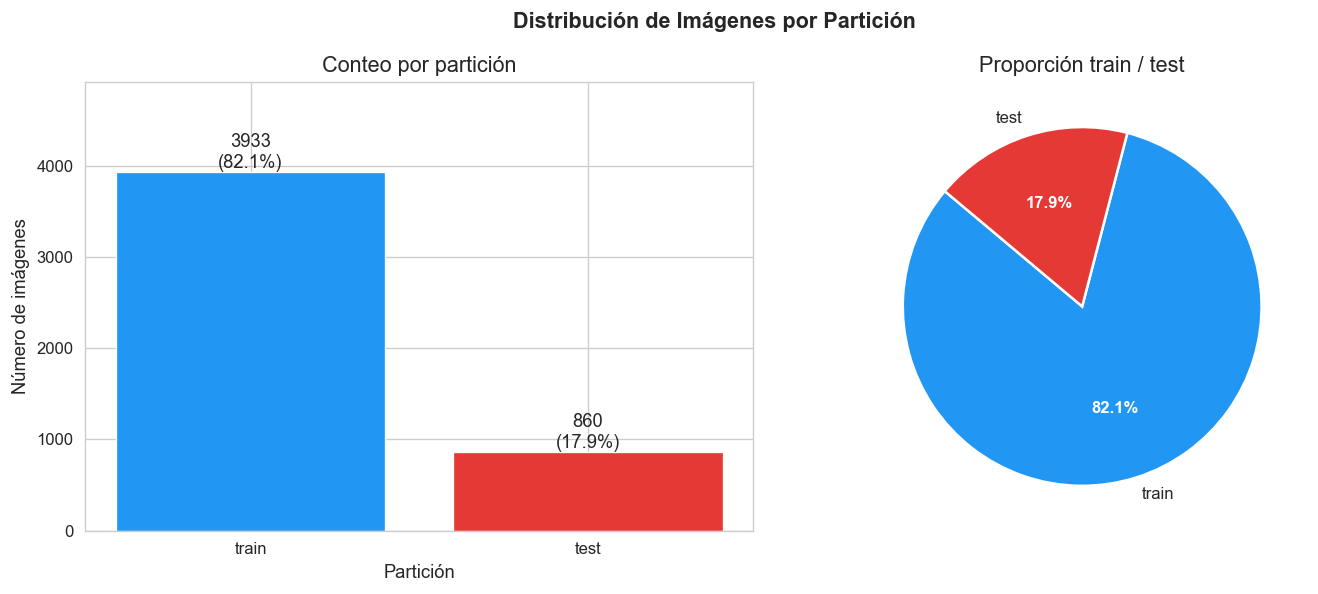

Figura guardada: eda_02_distribucion_particiones.png


In [7]:
counts = df['Particion'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Imágenes por Partición', fontsize=13, fontweight='bold')

colores = [COLORES_PARTICION[p] for p in counts.index]
barras  = axes[0].bar(counts.index, counts.values, color=colores, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Partición')
axes[0].set_ylabel('Número de imágenes')
total = counts.sum()
for barra, val in zip(barras, counts.values):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
                 f'{val}\n({100*val/total:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.25)
axes[0].set_title('Conteo por partición')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    autopct='%1.1f%%', colors=colores, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title('Proporción train / test')

plt.tight_layout()
plt.savefig('eda_02_distribucion_particiones.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_02_distribucion_particiones.png')

La proporción 82/18 entre train y test es ligeramente más cargada hacia entrenamiento que el estándar 80/20, pero es adecuada para un dataset de segmentación médica de este tamaño. 

Con 860 imágenes de test el conjunto de evaluación es suficientemente grande para producir estimaciones estables del Dice Score sin necesidad de recurrir a 
validación cruzada.

### 4.2 Distribución del Tamaño de las Imágenes

El tamaño de entrada al modelo de segmentación debe ser fijo. En segmentación el redimensionamiento es más delicado que en clasificación: al redimensionar la imagen también se redimensiona la máscara, y si se usa interpolación bilineal sobre la máscara se introducen valores intermedios entre 0 y 255 que corrompan la anotación binaria. La interpolación correcta para las máscaras es siempre INTER_NEAREST.

Estadísticas de dimensiones por partición:
             alto                                                    ancho                                                  n_pixeles                                                                     
            count   mean   std    min    25%    50%    75%     max   count   mean   std    min    25%    50%    75%     max     count      mean      std      min       25%       50%       75%        max
Particion                                                                                                                                                                                                 
test        860.0  487.1  79.0  195.0  512.0  512.0  512.0  1019.0   860.0  484.6  85.5  174.0  512.0  512.0  512.0  1149.0     860.0  242580.1  68691.3  40020.0  262144.0  262144.0  262144.0  1170831.0
train      3933.0  505.6  50.0  202.0  512.0  512.0  512.0  1427.0  3933.0  505.0  51.5  180.0  512.0  512.0  512.0  1365.0    3933.0  257864.7  

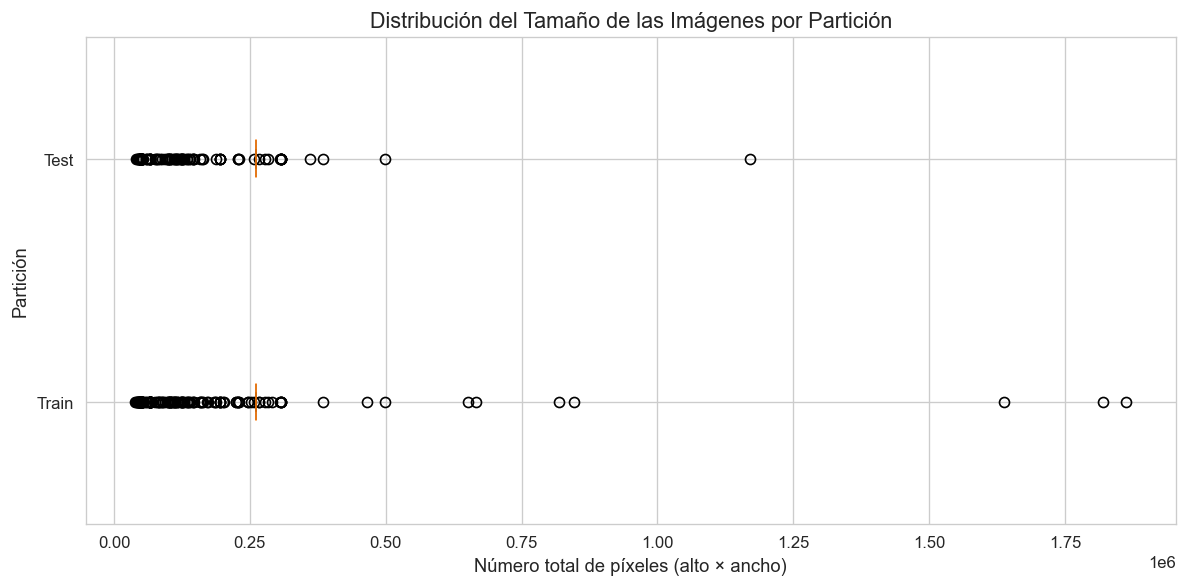

Figura guardada: eda_03_tamano_imagenes.png


In [8]:
print('Estadísticas de dimensiones por partición:')
print(df.groupby('Particion')[['alto', 'ancho', 'n_pixeles']].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
datos_box = [df[df['Particion'] == p]['n_pixeles'].values for p in PARTICIONES]
bp = ax.boxplot(datos_box, patch_artist=True,
                labels=[p.capitalize() for p in PARTICIONES], vert=False)
for patch, p in zip(bp['boxes'], PARTICIONES):
    patch.set_facecolor(COLORES_PARTICION[p])
    patch.set_alpha(0.75)
ax.set_xlabel('Número total de píxeles (alto × ancho)')
ax.set_ylabel('Partición')
ax.set_title('Distribución del Tamaño de las Imágenes por Partición')
plt.tight_layout()
plt.savefig('eda_03_tamano_imagenes.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_03_tamano_imagenes.png')

El percentil 25, la mediana y el percentil 75 de n_pixeles coinciden en 262144 
(512×512) en ambas particiones, lo que indica que la resolución dominante es 512×512. 

Sin embargo, la presencia de valores mínimos en torno a 40000 px y máximos superiores 
a 1 millón de píxeles revela casos atípicos que deben redimensionarse antes del entrenamiento. Se confirma la necesidad de una resolución de entrada fija, con 256×256 como opción razonable que reduce el costo computacional a la mitad sin perder la estructura anatómica relevante.

### 4.3 Análisis de Dimensiones: Ancho vs Alto

El scatter de ancho frente a alto permite identificar si las imágenes tienen una resolución estándar concentrada o alta dispersión. Si los puntos se agrupan cerca de la diagonal 1:1, las imágenes son aproximadamente cuadradas y un redimensionamiento directo a NxN introduce poca distorsión geométrica.

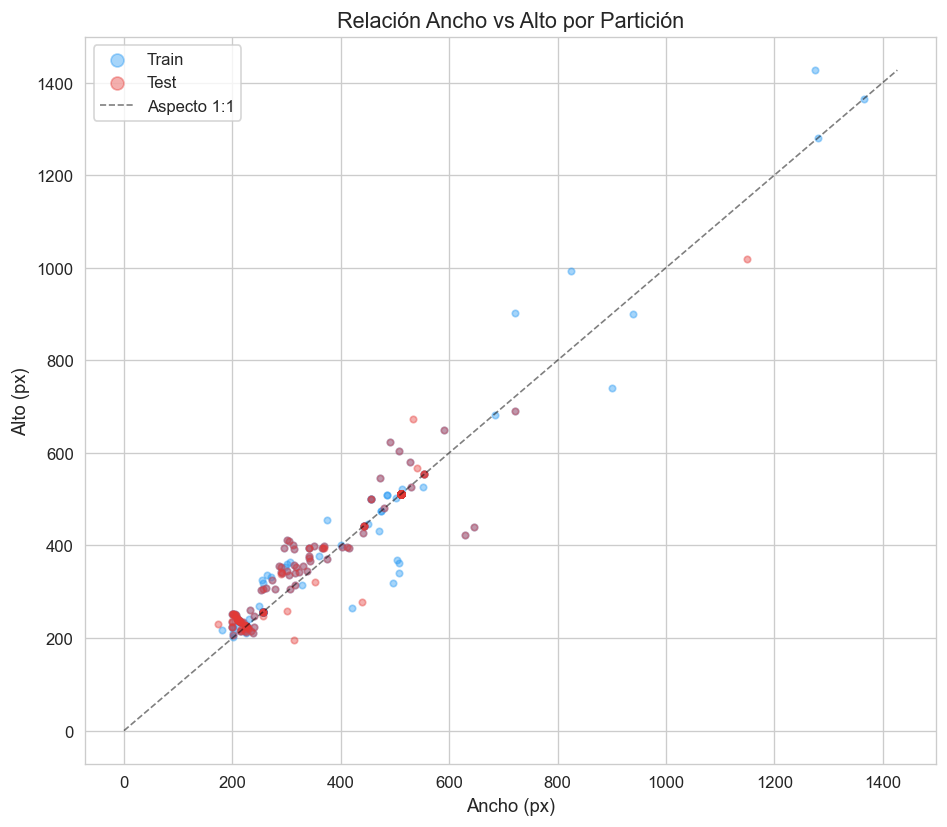

Figura guardada: eda_04_ancho_vs_alto.png

Resolución más frecuente por partición:
  train: ['512x512', '256x256', '225x225'] (conteos: [3766, 25, 8])
  test: ['512x512', '225x225', '256x256'] (conteos: [738, 7, 5])


In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

for p in PARTICIONES:
    sub = df[df['Particion'] == p]
    ax.scatter(sub['ancho'], sub['alto'], alpha=0.4, s=15,
               label=p.capitalize(), color=COLORES_PARTICION[p])

max_dim = max(df['ancho'].max(), df['alto'].max())
ax.plot([0, max_dim], [0, max_dim], 'k--', linewidth=1, alpha=0.5, label='Aspecto 1:1')
ax.set_xlabel('Ancho (px)')
ax.set_ylabel('Alto (px)')
ax.set_title('Relación Ancho vs Alto por Partición')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig('eda_04_ancho_vs_alto.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_04_ancho_vs_alto.png')

# Resolución más frecuente por partición
df['resolucion'] = df['ancho'].astype(str) + 'x' + df['alto'].astype(str)
print('\nResolución más frecuente por partición:')
for p in PARTICIONES:
    top = df[df['Particion'] == p]['resolucion'].value_counts().head(3)
    print(f'  {p}: {list(top.index)} (conteos: {list(top.values)})')

La resolución dominante es 512×512 en ambas particiones, con 3766 casos en train y 738 en test. Los puntos del scatter se concentran sobre la diagonal 1:1, confirmando que las imágenes son mayoritariamente cuadradas y que un redimensionamiento directo a 256×256 no introducirá distorsión geométrica significativa en la mayoría de los casos. 

Los pocos casos fuera de la diagonal (resoluciones como 225×225 y algunas superiores a 512) representan una minoría manejable con padding o crop antes del redimensionamiento.

### 4.4 Mapa de Intensidad de Píxeles

El mapa de calor sobre la escala de grises permite visualizar la distribución espacial de la señal MRI. En MRI, las intensidades reflejan propiedades del tejido: el tumor puede aparecer como una región hiperintensa o hipointensa respecto al parénquima circundante dependiendo de la secuencia de adquisición. El mapa de calor de la máscara confirma el patrón binario esperado: una región concentrada de alta intensidad sobre un fondo de valor cero.

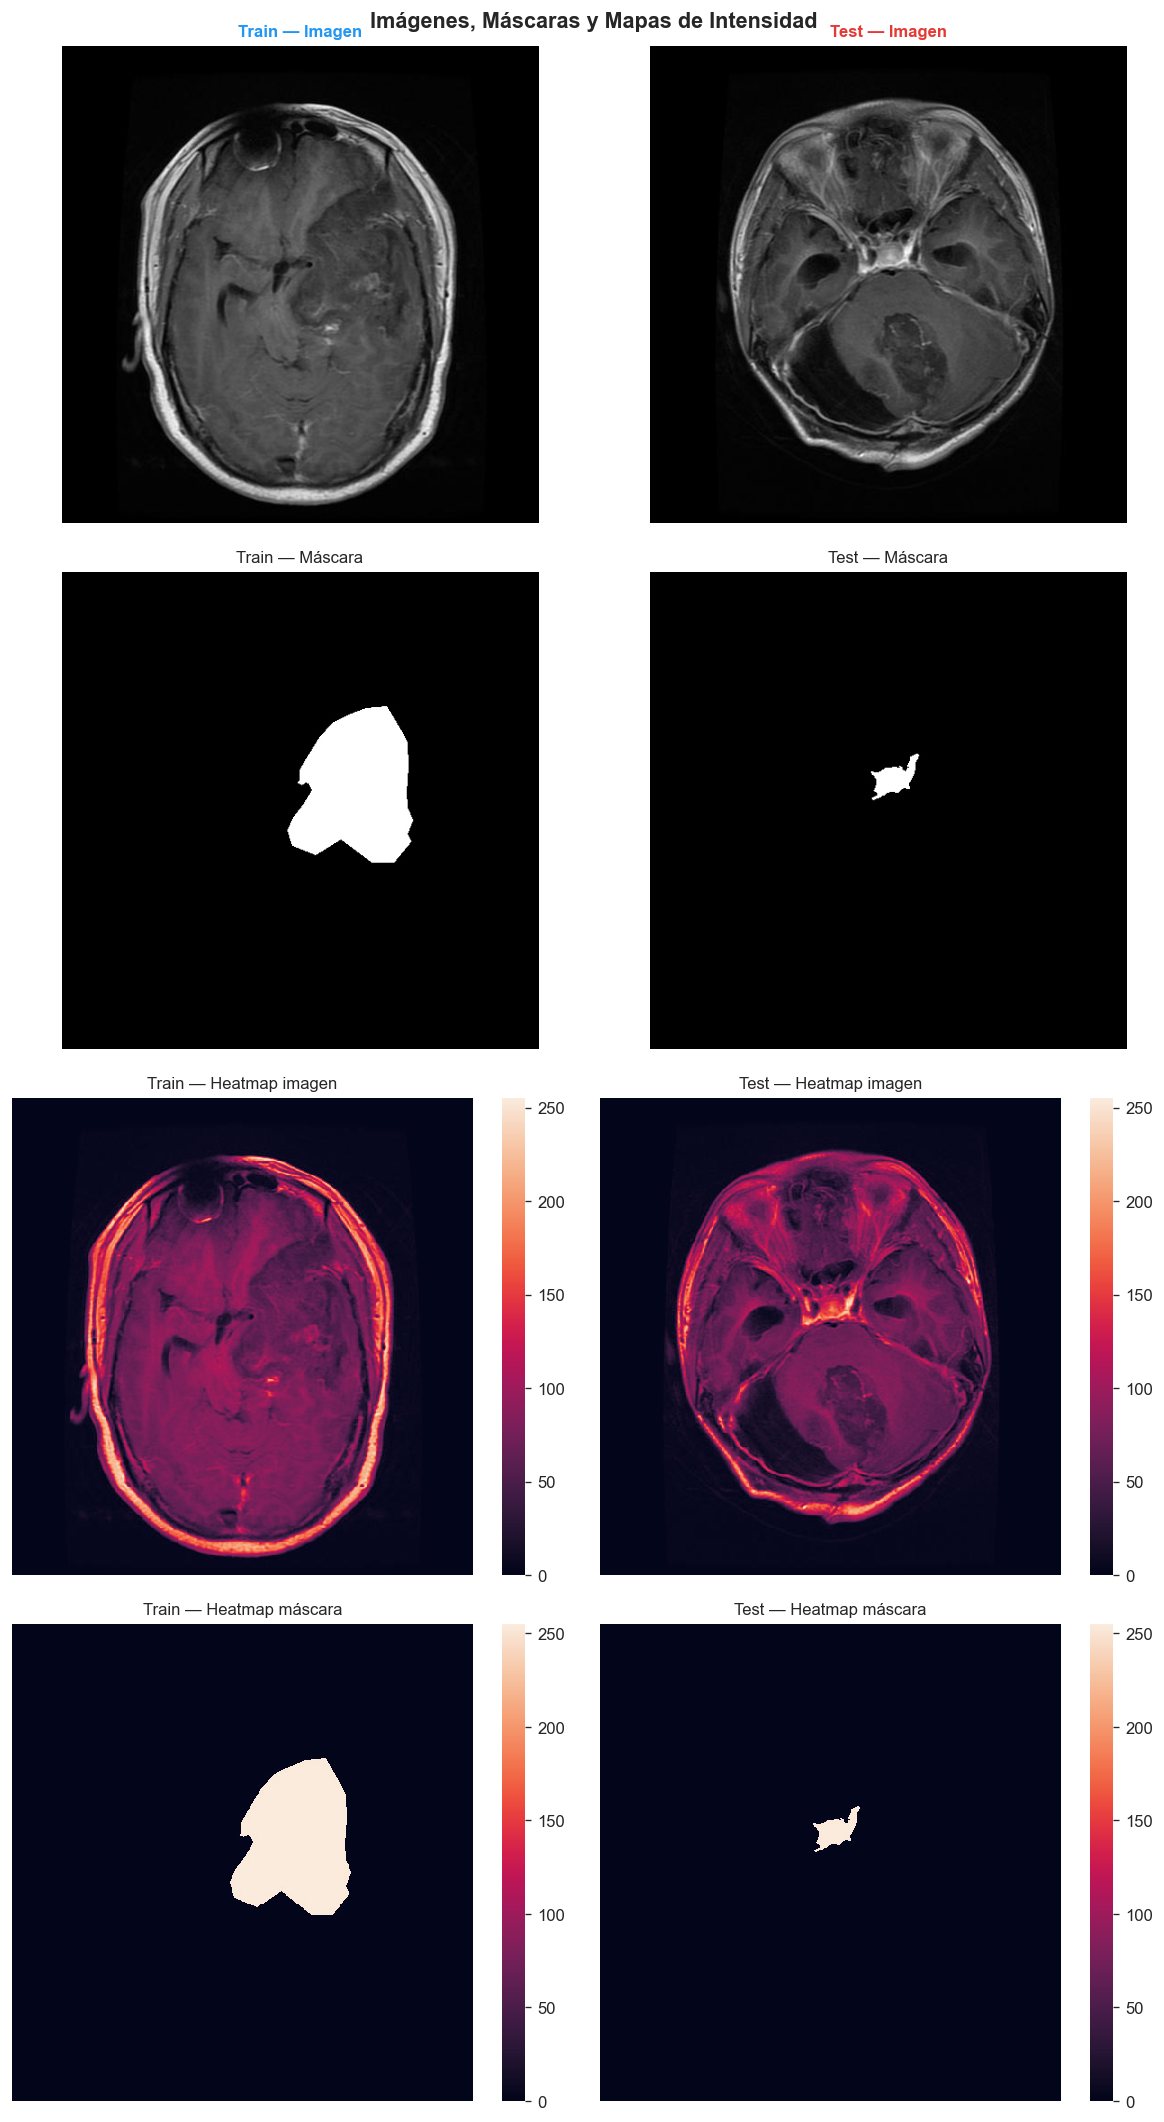

Figura guardada: eda_05_heatmaps.png


In [10]:
fig, axes = plt.subplots(4, 2, figsize=(10, 18))
fig.suptitle('Imágenes, Máscaras y Mapas de Intensidad', fontsize=13, fontweight='bold')

for i, particion in enumerate(PARTICIONES):
    dir_img = BASE_PATH / particion / 'images'
    dir_msk = BASE_PATH / particion / 'masks'

    rutas_img = sorted(glob(str(dir_img / '*.png')), key=extraer_numero)
    if not rutas_img:
        rutas_img = sorted(glob(str(dir_img / '*.jpg')), key=extraer_numero)

    ruta_img    = rutas_img[0]
    nombre      = os.path.basename(ruta_img)
    nombre_base = os.path.splitext(nombre)[0]
    ruta_msk    = dir_msk / nombre
    if not ruta_msk.exists():
        ruta_msk = dir_msk / (nombre_base + '.png')

    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(str(ruta_msk), cv2.IMREAD_GRAYSCALE) if ruta_msk.exists() else np.zeros_like(img)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{particion.capitalize()} — Imagen', fontsize=10,
                          color=COLORES_PARTICION[particion], fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(msk, cmap='gray')
    axes[1, i].set_title(f'{particion.capitalize()} — Máscara', fontsize=10)
    axes[1, i].axis('off')

    sns.heatmap(img, cmap='rocket', cbar=True, ax=axes[2, i],
                xticklabels=False, yticklabels=False)
    axes[2, i].set_title(f'{particion.capitalize()} — Heatmap imagen', fontsize=10)

    sns.heatmap(msk, cmap='rocket', cbar=True, ax=axes[3, i],
                xticklabels=False, yticklabels=False)
    axes[3, i].set_title(f'{particion.capitalize()} — Heatmap máscara', fontsize=10)

plt.tight_layout()
plt.savefig('eda_05_heatmaps.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_05_heatmaps.png')

Los heatmaps confirman que la señal MRI está concentrada en la región cerebral 
central, con intensidades bajas en el fondo exterior. En las máscaras, la región de alta intensidad es localizada y ocupa una fracción pequeña del total de píxeles, lo que anticipa el desbalance foreground/background que se cuantifica en la sección 4.7.

### 4.5 Histograma de Escala de Grises

El histograma de intensidades describe cómo se distribuyen los valores de píxel en la imagen. En imágenes MRI cerebrales el histograma suele ser multimodal: un pico en intensidades bajas corresponde al fondo, un pico en intensidades medias al parénquima cerebral, y un posible tercer componente de alta intensidad puede corresponder a la región tumoral o a zonas de realce. Esta estructura informa la elección de la estrategia de normalización antes del entrenamiento.

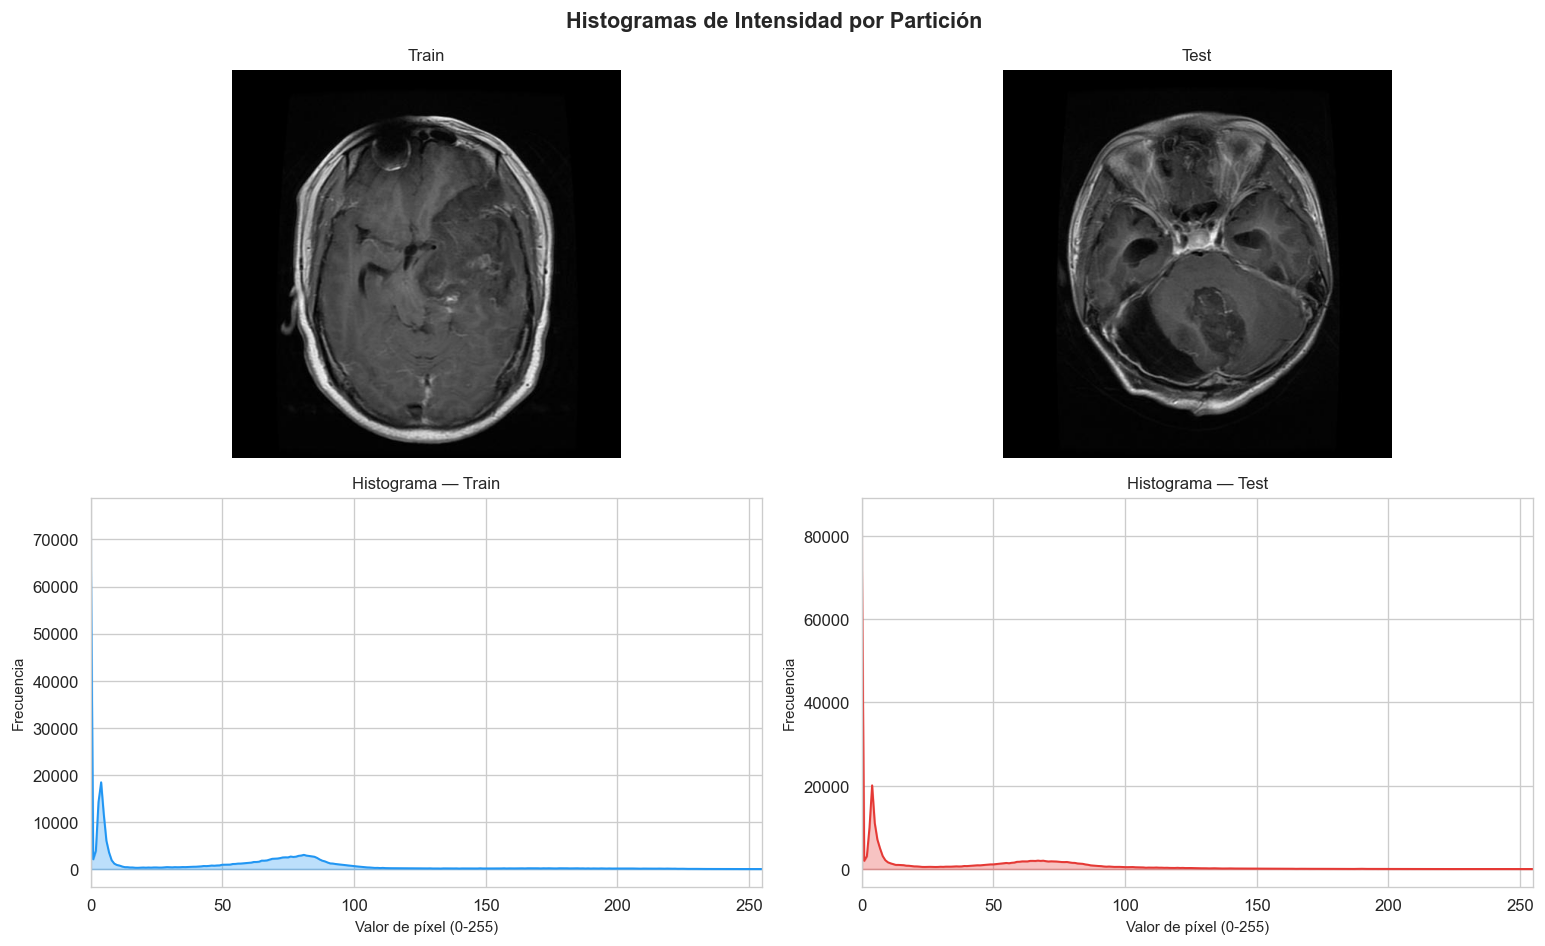

Figura guardada: eda_06_histogramas_grises.png


In [11]:
def mostrar_histograma(img_gris, titulo, ax_img, ax_hist, color):
    """Muestra imagen y su histograma de escala de grises lado a lado."""
    ax_img.imshow(img_gris, cmap='gray')
    ax_img.set_title(titulo, fontsize=10)
    ax_img.axis('off')

    hist = cv2.calcHist([img_gris], [0], None, [256], [0, 256]).flatten()
    ax_hist.plot(hist, color=color, linewidth=1.2)
    ax_hist.fill_between(range(256), hist, alpha=0.3, color=color)
    ax_hist.set_xlabel('Valor de píxel (0-255)', fontsize=9)
    ax_hist.set_ylabel('Frecuencia', fontsize=9)
    ax_hist.set_xlim(0, 255)
    ax_hist.set_title(f'Histograma — {titulo}', fontsize=10)

fig, axes = plt.subplots(2, len(PARTICIONES), figsize=(13, 8))
fig.suptitle('Histogramas de Intensidad por Partición', fontsize=13, fontweight='bold')

for i, particion in enumerate(PARTICIONES):
    dir_img  = BASE_PATH / particion / 'images'
    rutas    = sorted(glob(str(dir_img / '*.png')), key=extraer_numero)
    if not rutas:
        rutas = sorted(glob(str(dir_img / '*.jpg')), key=extraer_numero)
    img      = cv2.imread(rutas[0], cv2.IMREAD_GRAYSCALE)
    mostrar_histograma(img, particion.capitalize(),
                       axes[0, i], axes[1, i],
                       COLORES_PARTICION[particion])

plt.tight_layout()
plt.savefig('eda_06_histogramas_grises.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_06_histogramas_grises.png')

Los histogramas presentan una distribución fuertemente sesgada hacia valores bajos de intensidad, con un pico pronunciado cerca de cero que corresponde al fondo negro de la imagen. El parénquima cerebral aparece como un segundo componente en intensidades medias, sin un tercer pico claramente separable que identifique el tumor, lo que confirma que la segmentación no puede resolverse con un simple umbral de intensidad y requiere un modelo que capture contexto espacial. Esta estructura justifica el uso de normalización z-score por imagen en lugar de min-max, que quedaría distorsionada por el pico dominante en cero.

### 4.6 Distribución de Intensidad: Train vs Test

Se superponen las distribuciones de intensidad de train y test para verificar que sean comparables. Si las distribuciones difieren significativamente, el modelo puede encontrar en test una distribución de entrada distinta a la que vio durante el entrenamiento, lo que puede degradar el Dice Score por un efecto de domain shift y no necesariamente por limitaciones del modelo.

Calculando distribuciones de intensidad (60 imágenes por partición)...


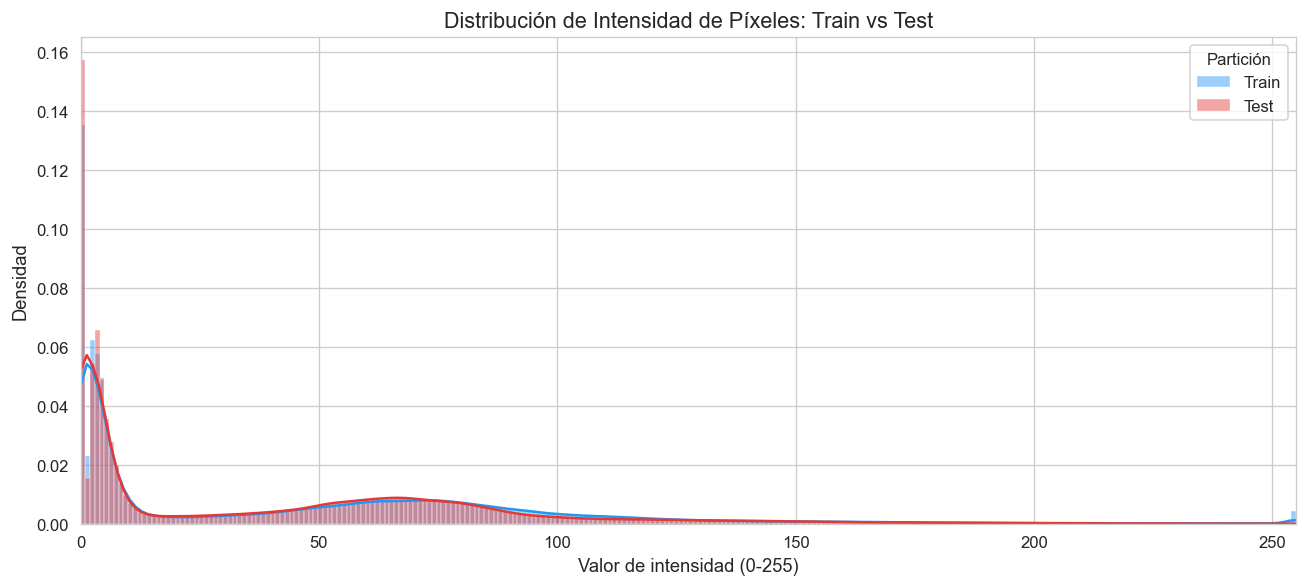

Figura guardada: eda_07_distribucion_intensidad.png

Estadísticos de intensidad por partición:
  train     media=43.0  std=44.0  p5=0.0  p95=124.0
  test      media=42.0  std=43.9  p5=0.0  p95=123.0


In [12]:
N_MUESTRAS_HIST = 60

print(f'Calculando distribuciones de intensidad ({N_MUESTRAS_HIST} imágenes por partición)...')

fig, ax = plt.subplots(figsize=(11, 5))

for particion in PARTICIONES:
    dir_img  = BASE_PATH / particion / 'images'
    rutas    = glob(str(dir_img / '*.png')) + glob(str(dir_img / '*.jpg'))
    muestra  = random.sample(rutas, min(N_MUESTRAS_HIST, len(rutas)))

    pixeles  = np.concatenate([
        cv2.imread(r, cv2.IMREAD_GRAYSCALE).flatten()
        for r in muestra if cv2.imread(r, cv2.IMREAD_GRAYSCALE) is not None
    ])
    sns.histplot(pixeles, bins=256, kde=True,
                 color=COLORES_PARTICION[particion], label=particion.capitalize(),
                 alpha=0.45, ax=ax, stat='density')

ax.set_xlabel('Valor de intensidad (0-255)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Intensidad de Píxeles: Train vs Test')
ax.legend(title='Partición')
ax.set_xlim(0, 255)
plt.tight_layout()
plt.savefig('eda_07_distribucion_intensidad.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_07_distribucion_intensidad.png')

print('\nEstadísticos de intensidad por partición:')
for particion in PARTICIONES:
    dir_img = BASE_PATH / particion / 'images'
    rutas   = glob(str(dir_img / '*.png')) + glob(str(dir_img / '*.jpg'))
    muestra = random.sample(rutas, min(N_MUESTRAS_HIST, len(rutas)))
    pixeles = np.concatenate([
        cv2.imread(r, cv2.IMREAD_GRAYSCALE).flatten()
        for r in muestra if cv2.imread(r, cv2.IMREAD_GRAYSCALE) is not None
    ])
    print(f'  {particion:<8}  media={pixeles.mean():.1f}  std={pixeles.std():.1f}  '
          f'p5={np.percentile(pixeles,5):.1f}  p95={np.percentile(pixeles,95):.1f}')

Las distribuciones de intensidad de train y test son prácticamente idénticas: 
media 43.0 vs 42.0, std 44.0 vs 43.9, y percentil 95 de 124 vs 123. Esta similitud indica que no hay domain shift en términos de distribución de píxeles entre particiones, y que la estrategia de normalización calculada sobre train puede aplicarse sobre test sin degradación adicional.

### 4.7 Carga Tumoral: Desbalance Foreground/Background

Esta es la sección más crítica del EDA para la tarea de segmentación. El desbalance entre píxeles de tumor (foreground) y píxeles de fondo (background) determina directamente la elección de la función de pérdida.

En segmentación médica el tumor típicamente ocupa una fracción pequeña de la imagen. Si se usa Binary Cross-Entropy estándar, el modelo aprende rápidamente a predecir todo como fondo y obtiene una accuracy alta pero un Dice Score cercano a cero. La solución habitual es Dice Loss, que optimiza directamente la superposición entre la predicción y la máscara, o una combinación de BCE ponderado y Dice.

In [13]:
print('Estadísticos de carga tumoral por partición:')
print(df.groupby('Particion')['pct_tumor'].describe().round(3).to_string())

print('\nImágenes con pct_tumor == 0 (sin tumor visible) por partición:')
for p in PARTICIONES:
    sub   = df[df['Particion'] == p]
    n_sin = (sub['pct_tumor'] == 0).sum()
    print(f'  {p}: {n_sin} de {len(sub)} ({100*n_sin/len(sub):.1f}%)')

print('\nRatio foreground/background por partición:')
for p in PARTICIONES:
    sub       = df[df['Particion'] == p]
    pct_media = sub[sub['pct_tumor'] > 0]['pct_tumor'].mean()
    ratio     = (100 - pct_media) / pct_media if pct_media > 0 else float('inf')
    print(f'  {p:<8}: {pct_media:.2f}% tumor en promedio  ->  '
          f'ratio fondo/tumor = {ratio:.1f}x')

Estadísticos de carga tumoral por partición:
            count   mean    std    min    25%    50%    75%     max
Particion                                                          
test        860.0  2.115  2.034  0.127  0.780  1.416  2.751  16.700
train      3933.0  1.835  1.477  0.041  0.859  1.438  2.321  19.609

Imágenes con pct_tumor == 0 (sin tumor visible) por partición:
  train: 0 de 3933 (0.0%)
  test: 0 de 860 (0.0%)

Ratio foreground/background por partición:
  train   : 1.83% tumor en promedio  ->  ratio fondo/tumor = 53.5x
  test    : 2.12% tumor en promedio  ->  ratio fondo/tumor = 46.3x


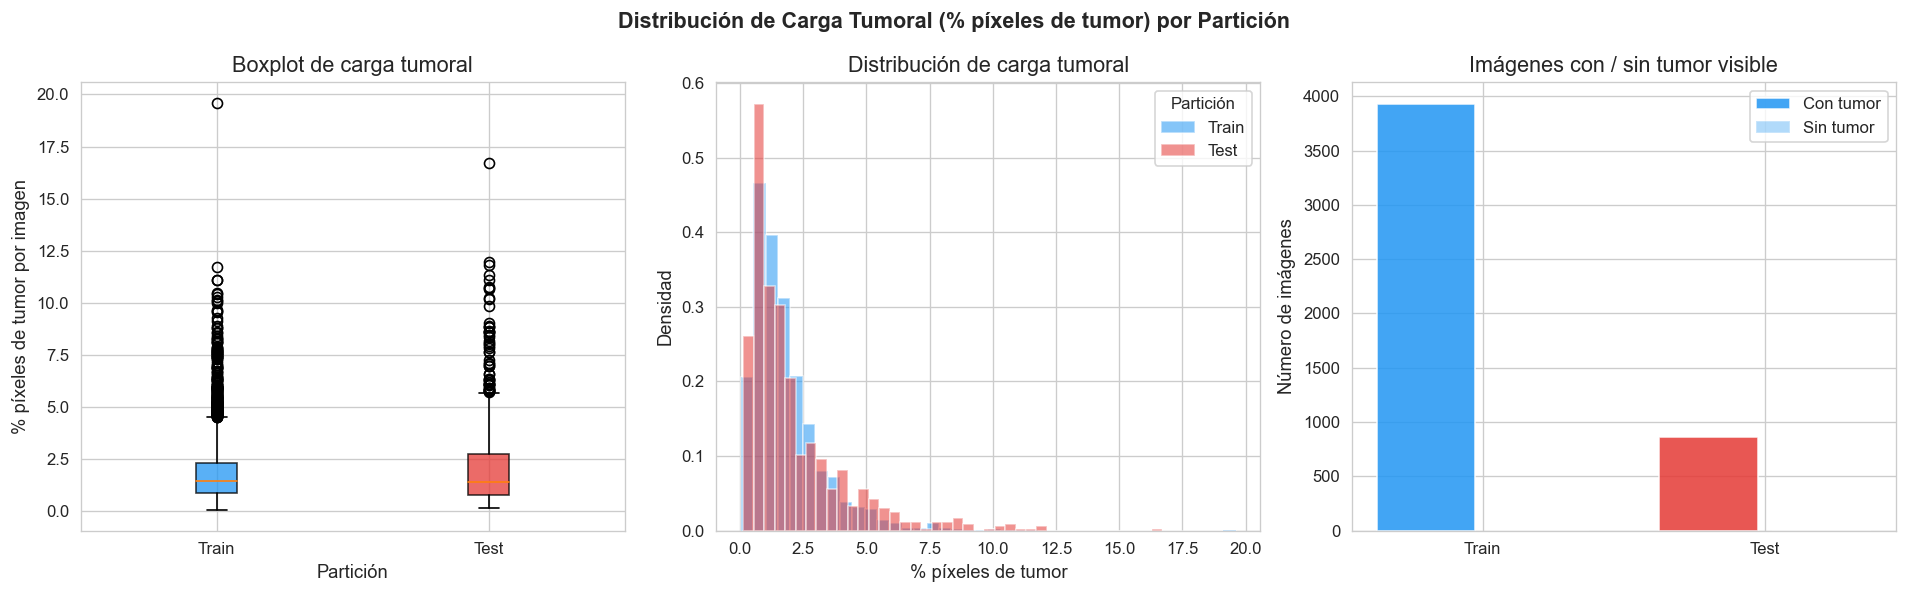

Figura guardada: eda_08_carga_tumoral.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Carga Tumoral (% píxeles de tumor) por Partición',
             fontsize=13, fontweight='bold')

# Boxplot
datos_box = [df[df['Particion'] == p]['pct_tumor'].values for p in PARTICIONES]
bp = axes[0].boxplot(datos_box, patch_artist=True,
                     labels=[p.capitalize() for p in PARTICIONES])
for patch, p in zip(bp['boxes'], PARTICIONES):
    patch.set_facecolor(COLORES_PARTICION[p])
    patch.set_alpha(0.75)
axes[0].set_ylabel('% píxeles de tumor por imagen')
axes[0].set_title('Boxplot de carga tumoral')
axes[0].set_xlabel('Partición')

# Histograma superpuesto
for p in PARTICIONES:
    sub = df[df['Particion'] == p]
    axes[1].hist(sub['pct_tumor'], bins=40, alpha=0.55,
                 color=COLORES_PARTICION[p], label=p.capitalize(), density=True)
axes[1].set_xlabel('% píxeles de tumor')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de carga tumoral')
axes[1].legend(title='Partición')

# Imágenes con / sin tumor
for i, p in enumerate(PARTICIONES):
    sub   = df[df['Particion'] == p]
    n_con = (sub['pct_tumor'] > 0).sum()
    n_sin = (sub['pct_tumor'] == 0).sum()
    axes[2].bar(i - 0.2, n_con, 0.35,
                label='Con tumor' if i == 0 else '',
                color=COLORES_PARTICION[p], alpha=0.85)
    axes[2].bar(i + 0.2, n_sin, 0.35,
                label='Sin tumor' if i == 0 else '',
                color=COLORES_PARTICION[p], alpha=0.35)
axes[2].set_xticks(range(len(PARTICIONES)))
axes[2].set_xticklabels([p.capitalize() for p in PARTICIONES])
axes[2].set_ylabel('Número de imágenes')
axes[2].set_title('Imágenes con / sin tumor visible')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_08_carga_tumoral.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_08_carga_tumoral.png')

La mediana de pct_tumor es 1.44% en train y 1.42% en test, con ratios fondo/tumor de 53.5x y 46.3x respectivamente. Este es el hallazgo más relevante del EDA: **por cada píxel de tumor hay aproximadamente 50 píxeles de fondo**, lo que hace que **Binary Cross-Entropy estándar sea directamente inapropiada** — el modelo podría alcanzar más del 98% de accuracy prediciendo todo como fondo. 

Ninguna imagen tiene pct_tumor igual a cero, lo que simplifica el manejo del dataset: no hay casos sin tumor que requieran tratamiento especial durante el entrenamiento.

---
## 5. Análisis de Brillo y Contraste

Se calculan el brillo medio, el contraste RMS y la entropía de cada imagen para detectar diferencias sistemáticas entre particiones. Si train y test tienen perfiles de brillo similares, no hay evidencia de domain shift en esta dimensión.

In [15]:
print('Calculando brillo y contraste por imagen...')

registros_brillo = []
for _, row in df.iterrows():
    dir_img     = BASE_PATH / row['Particion'] / 'images'
    ruta_img    = dir_img / row['Nombre']
    img         = cv2.imread(str(ruta_img), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img_f       = img.astype(float)
    brillo      = img_f.mean()
    contraste   = img_f.std()
    hist_e, _   = np.histogram(img.flatten(), bins=256, range=(0,256), density=True)
    hist_e      = hist_e[hist_e > 0]
    entropia    = -np.sum(hist_e * np.log2(hist_e))

    registros_brillo.append({
        'Particion':     row['Particion'],
        'brillo_medio':  brillo,
        'contraste_rms': contraste,
        'entropia':      entropia
    })

df_brillo = pd.DataFrame(registros_brillo)
print('\nEstadísticos de brillo, contraste y entropía por partición:')
print(df_brillo.groupby('Particion')[['brillo_medio', 'contraste_rms', 'entropia']]
      .describe().round(2).to_string())

Calculando brillo y contraste por imagen...

Estadísticos de brillo, contraste y entropía por partición:
          brillo_medio                                                   contraste_rms                                                 entropia                                         
                 count   mean    std    min    25%    50%    75%     max         count   mean   std    min    25%    50%    75%    max    count  mean   std   min   25%  50%   75%   max
Particion                                                                                                                                                                               
test             860.0  45.42  16.23  17.36  34.67  42.90  51.64  137.76         860.0  44.32  9.74  22.98  38.34  42.52  47.42  90.85    860.0  5.93  0.73  3.17  5.51  6.0  6.50  7.73
train           3933.0  42.49  12.48  13.69  33.83  41.83  50.14  137.76        3933.0  42.38  7.00  20.83  38.34  42.02  45.85  90.85   3933.0  5.88  0.75

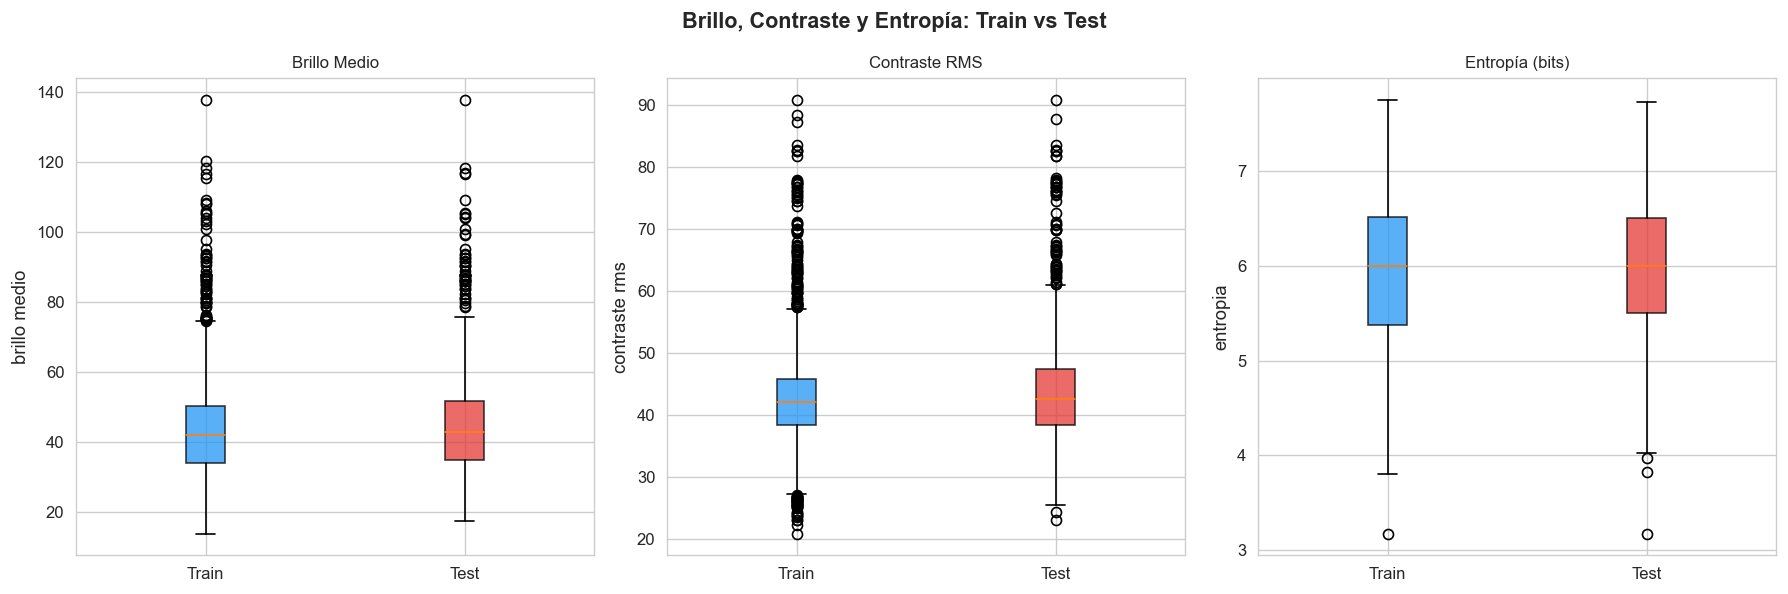

Figura guardada: eda_09_brillo_contraste.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Brillo, Contraste y Entropía: Train vs Test', fontsize=13, fontweight='bold')

metricas = [
    ('brillo_medio',  'Brillo Medio'),
    ('contraste_rms', 'Contraste RMS'),
    ('entropia',      'Entropía (bits)')
]

for ax, (metrica, titulo) in zip(axes, metricas):
    datos = [df_brillo[df_brillo['Particion'] == p][metrica].values for p in PARTICIONES]
    bp    = ax.boxplot(datos, patch_artist=True,
                       labels=[p.capitalize() for p in PARTICIONES])
    for patch, p in zip(bp['boxes'], PARTICIONES):
        patch.set_facecolor(COLORES_PARTICION[p])
        patch.set_alpha(0.75)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel(metrica.replace('_', ' '))

plt.tight_layout()
plt.savefig('eda_09_brillo_contraste.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_09_brillo_contraste.png')

Train y test presentan perfiles similares en contraste RMS (42.38 vs 44.32) y 
entropía (5.88 vs 5.93), con diferencias marginales. El brillo medio difiere 
ligeramente (42.49 vs 45.42), diferencia que la prueba estadística de la sección 8 confirma como significativa. Dado que la diferencia absoluta es pequeña en escala 0-255, la normalización z-score por imagen es suficiente para absorberla sin necesidad de ajustes adicionales por partición.

---
## 6. Imagen Promedio y Mapa de Variabilidad

La imagen promedio revela la anatomía promedio del dataset y la ubicación más frecuente del tumor. El mapa de variabilidad indica qué regiones presentan más diferencia entre casos. En segmentación, una alta variabilidad en la región tumoral es esperable: el modelo debe aprender a segmentar tumores de distintos tamaños, formas y localizaciones.

In [17]:
TAMANO_PROM = (256, 256)
N_PROM      = 80

print(f'Calculando imagen promedio ({N_PROM} imágenes, {TAMANO_PROM}px)...')

imagenes_prom    = {}
imagenes_std_map = {}
mascaras_prom    = {}

for particion in PARTICIONES:
    dir_img  = BASE_PATH / particion / 'images'
    dir_msk  = BASE_PATH / particion / 'masks'
    rutas    = glob(str(dir_img / '*.png')) + glob(str(dir_img / '*.jpg'))
    muestra  = random.sample(rutas, min(N_PROM, len(rutas)))

    acum     = np.zeros(TAMANO_PROM, dtype=np.float64)
    acum_sq  = np.zeros(TAMANO_PROM, dtype=np.float64)
    acum_msk = np.zeros(TAMANO_PROM, dtype=np.float64)
    n_val    = 0

    for ruta_img in muestra:
        img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img_res  = cv2.resize(img.astype(np.float64), TAMANO_PROM, interpolation=cv2.INTER_AREA)
        acum    += img_res
        acum_sq += img_res ** 2
        n_val   += 1

        nombre      = os.path.basename(ruta_img)
        nombre_base = os.path.splitext(nombre)[0]
        ruta_msk    = dir_msk / nombre
        if not ruta_msk.exists():
            ruta_msk = dir_msk / (nombre_base + '.png')
        if ruta_msk.exists():
            msk     = cv2.imread(str(ruta_msk), cv2.IMREAD_GRAYSCALE)
            if msk is not None:
                msk_res  = cv2.resize(msk.astype(np.float64), TAMANO_PROM,
                                      interpolation=cv2.INTER_NEAREST)
                acum_msk += (msk_res > 0).astype(float)

    if n_val > 0:
        prom = acum / n_val
        var  = acum_sq / n_val - prom ** 2
        imagenes_prom[particion]    = np.clip(prom, 0, 255).astype(np.uint8)
        imagenes_std_map[particion] = np.clip(np.sqrt(np.maximum(var, 0)), 0, 255).astype(np.uint8)
        mascaras_prom[particion]    = (acum_msk / n_val * 255).astype(np.uint8)
    print(f'  {particion}: {n_val} imágenes procesadas.')

Calculando imagen promedio (80 imágenes, (256, 256)px)...
  train: 80 imágenes procesadas.
  test: 80 imágenes procesadas.


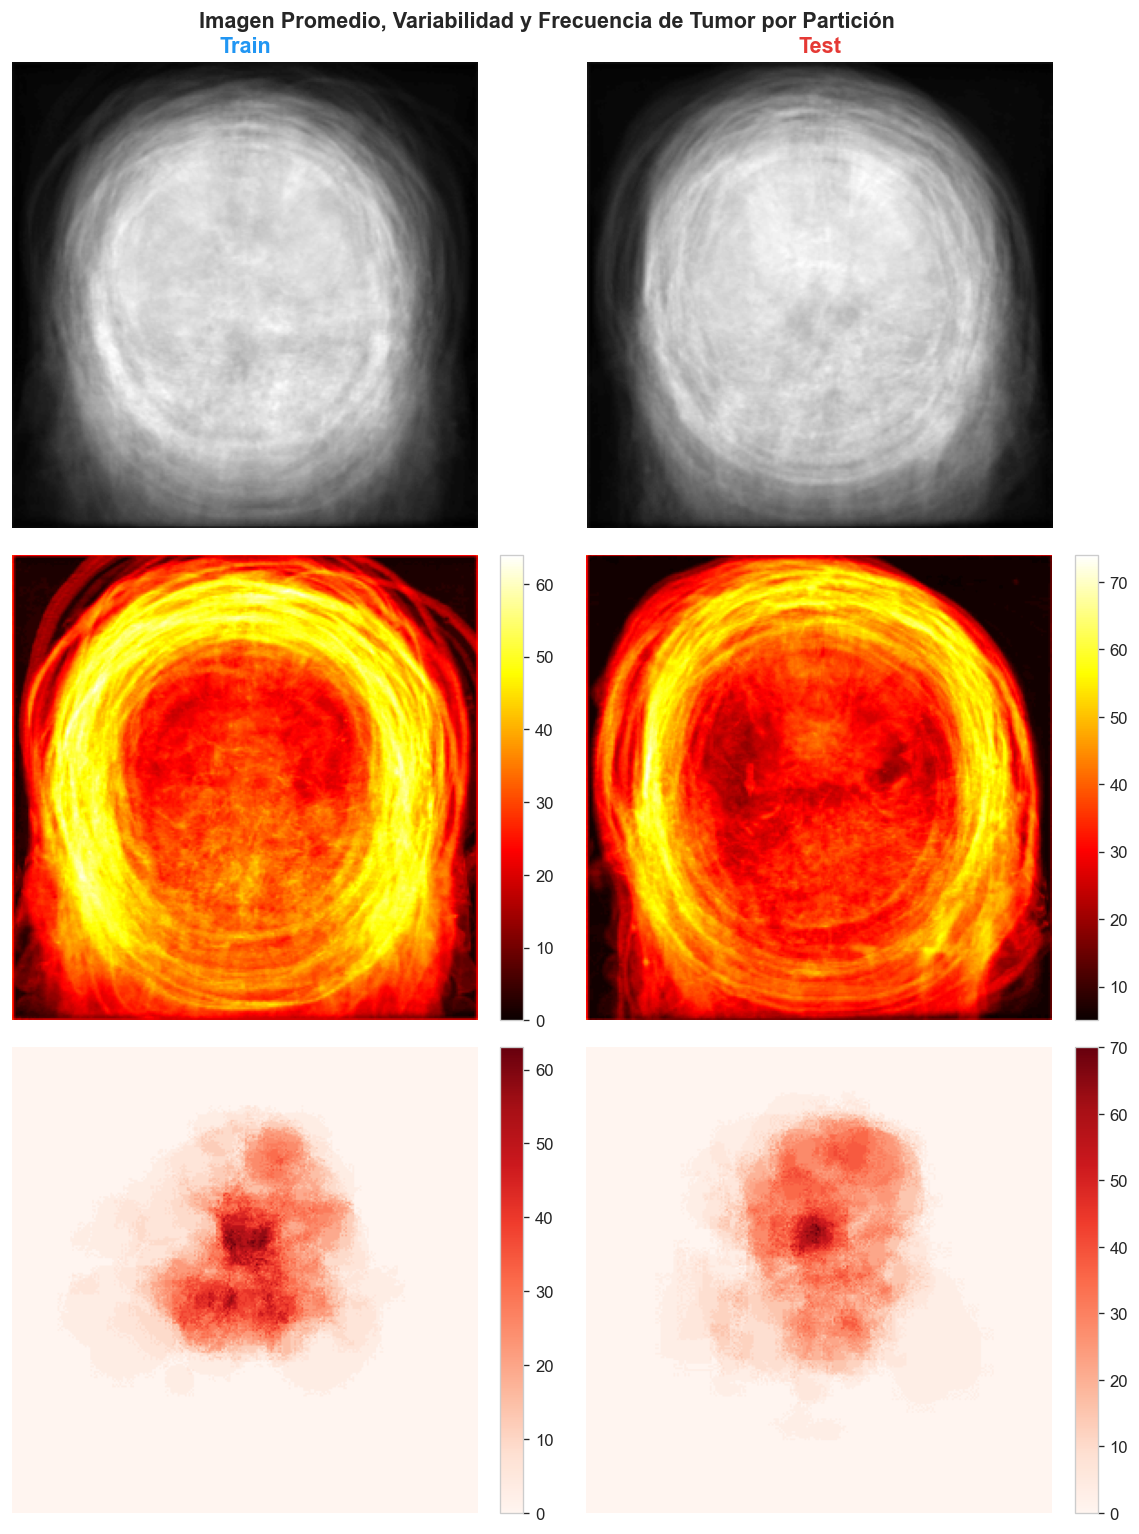

Figura guardada: eda_10_imagen_promedio.png


In [18]:
fig, axes = plt.subplots(3, len(PARTICIONES), figsize=(10, 13))
fig.suptitle('Imagen Promedio, Variabilidad y Frecuencia de Tumor por Partición',
             fontsize=13, fontweight='bold')

for j, particion in enumerate(PARTICIONES):
    axes[0, j].imshow(imagenes_prom[particion], cmap='gray')
    axes[0, j].set_title(particion.capitalize(), fontweight='bold',
                          color=COLORES_PARTICION[particion])
    axes[0, j].axis('off')
    if j == 0:
        axes[0, j].set_ylabel('Imagen promedio', fontsize=9)

    im = axes[1, j].imshow(imagenes_std_map[particion], cmap='hot')
    axes[1, j].axis('off')
    plt.colorbar(im, ax=axes[1, j], fraction=0.046, pad=0.04)
    if j == 0:
        axes[1, j].set_ylabel('Mapa de variabilidad', fontsize=9)

    im2 = axes[2, j].imshow(mascaras_prom[particion], cmap='Reds')
    axes[2, j].axis('off')
    plt.colorbar(im2, ax=axes[2, j], fraction=0.046, pad=0.04)
    if j == 0:
        axes[2, j].set_ylabel('Frecuencia de tumor', fontsize=9)

plt.tight_layout()
plt.savefig('eda_10_imagen_promedio.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_10_imagen_promedio.png')

La imagen promedio de ambas particiones revela la estructura anatómica central 
del cerebro con buena definición, lo que indica que los cortes están razonablemente alineados entre sí. El mapa de variabilidad muestra mayor dispersión en los bordes del cráneo y en las regiones periventriculares, que son zonas de alta variabilidad inter-sujeto. El mapa de frecuencia de tumor no está concentrado en una subregión específica, lo que implica que el modelo no puede apoyarse en sesgos de localización y debe aprender a detectar el tumor en cualquier posición del corte.

---
## 7. Filtrado de Imágenes con OpenCV

Las imágenes MRI presentan ruido de tipo Rician, que se origina en la naturaleza compleja de la señal de resonancia magnética. Se comparan tres filtros clásicos para evaluar cuál preserva mejor los bordes del tumor. En segmentación los bordes son exactamente lo que el modelo debe aprender a delimitar, por lo que un filtro que los borre es contraproducente como paso de preprocesamiento.

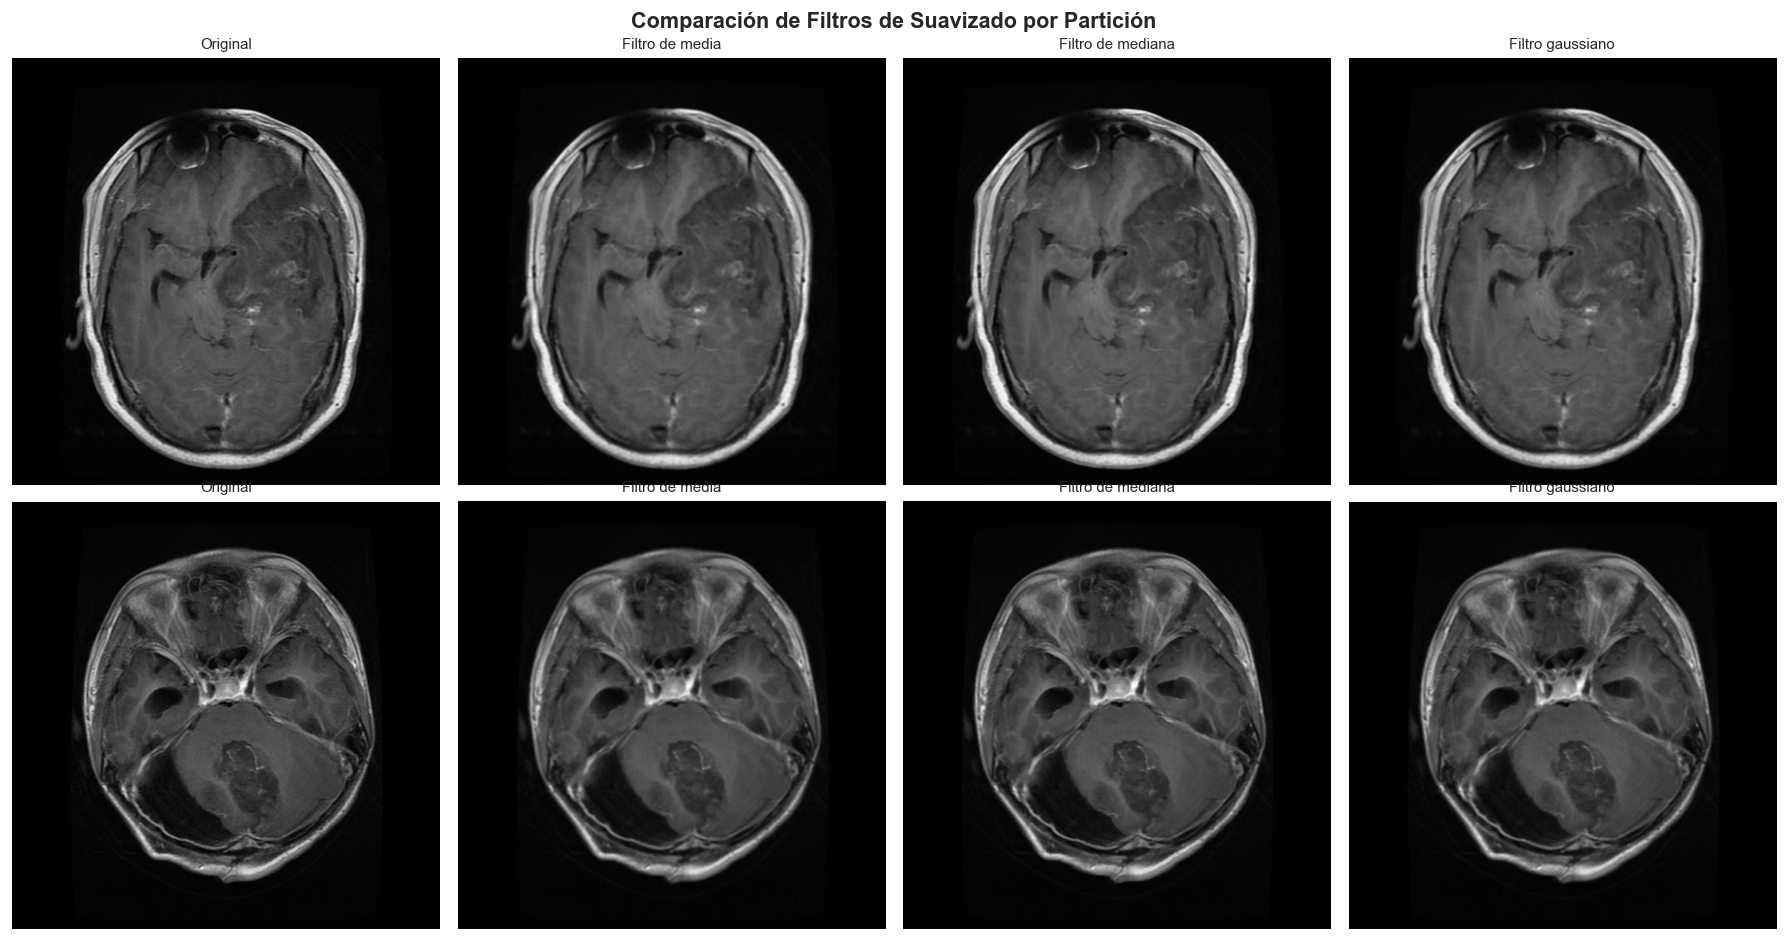

Figura guardada: eda_11_filtros.png


In [19]:
def aplicar_filtros_y_visualizar(img_gris, titulo, ax_arr):
    """Compara la imagen original con tres filtros de suavizado."""
    filtrada_media     = cv2.blur(img_gris, (3, 3))
    filtrada_mediana   = cv2.medianBlur(img_gris, 3)
    filtrada_gaussiana = cv2.GaussianBlur(img_gris, (3, 3), 0)

    variantes = [
        (img_gris,           'Original'),
        (filtrada_media,     'Filtro de media'),
        (filtrada_mediana,   'Filtro de mediana'),
        (filtrada_gaussiana, 'Filtro gaussiano')
    ]
    for ax, (img_v, nombre) in zip(ax_arr, variantes):
        ax.imshow(img_v, cmap='gray')
        ax.set_title(nombre, fontsize=9)
        ax.axis('off')
    ax_arr[0].set_ylabel(titulo, fontsize=9, rotation=90)

fig, axes = plt.subplots(len(PARTICIONES), 4, figsize=(15, 8))
fig.suptitle('Comparación de Filtros de Suavizado por Partición', fontsize=13, fontweight='bold')

for i, particion in enumerate(PARTICIONES):
    dir_img  = BASE_PATH / particion / 'images'
    rutas    = sorted(glob(str(dir_img / '*.png')), key=extraer_numero)
    if not rutas:
        rutas = sorted(glob(str(dir_img / '*.jpg')), key=extraer_numero)
    img      = cv2.imread(rutas[0], cv2.IMREAD_GRAYSCALE)
    aplicar_filtros_y_visualizar(img, particion.capitalize(), axes[i])

plt.tight_layout()
plt.savefig('eda_11_filtros.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_11_filtros.png')

El filtro de mediana preserva mejor los bordes del tumor que el de media y el 
gaussiano, que producen un suavizado más uniforme a costa de difuminar las 
transiciones abruptas entre tejido tumoral y parénquima sano. Dado que esos bordes son exactamente lo que la máscara anota y el modelo debe aprender a delimitar, no sería apropiado aplicar ningún filtro como paso estándar del pipeline de preprocesamiento, y se deja que la red aprenda a manejar el ruido inherente a la imagen.

---
## 8. Separabilidad Estadística entre Particiones

Se aplica la prueba de Mann-Whitney U sobre el brillo medio entre train y test para determinar si las distribuciones de intensidad son estadísticamente equivalentes. Si lo son, no hay evidencia de domain shift y el modelo puede generalizarse sin ajustes adicionales de normalización.

In [20]:
g_train = df_brillo[df_brillo['Particion'] == 'train']['brillo_medio'].values
g_test  = df_brillo[df_brillo['Particion'] == 'test']['brillo_medio'].values

u_stat, p_val = stats.mannwhitneyu(g_train, g_test, alternative='two-sided')
print('Prueba de Mann-Whitney U sobre brillo medio (train vs test):')
print(f'  Estadístico U = {u_stat:.4f},  p-valor = {p_val:.6f}')
if p_val < 0.05:
    print('  Conclusión: diferencia significativa entre particiones (p < 0.05).')
    print('  Recomendación: usar normalización z-score por imagen individual.')
else:
    print('  Conclusión: no se detecta diferencia significativa entre particiones.')
    print('  Recomendación: normalización global o por imagen son ambas adecuadas.')

# Estadísticos descriptivos comparados
print('\nComparación de estadísticos de brillo:')
for p in PARTICIONES:
    vals = df_brillo[df_brillo['Particion'] == p]['brillo_medio'].values
    print(f'  {p:<8}: media={vals.mean():.2f}  std={vals.std():.2f}  '
          f'mediana={np.median(vals):.2f}')

Prueba de Mann-Whitney U sobre brillo medio (train vs test):
  Estadístico U = 1580376.0000,  p-valor = 0.002574
  Conclusión: diferencia significativa entre particiones (p < 0.05).
  Recomendación: usar normalización z-score por imagen individual.

Comparación de estadísticos de brillo:
  train   : media=42.49  std=12.47  mediana=41.83
  test    : media=45.42  std=16.22  mediana=42.90


El p-valor de 0.0026 rechaza la hipótesis nula de distribuciones iguales en brillo 
entre train y test. Sin embargo, la diferencia de medias es de apenas 2.93 puntos 
en escala 0-255 (42.49 vs 45.42), lo que la hace estadísticamente significativa 
por el tamaño de la muestra pero no prácticamente relevante. La normalización 
z-score por imagen individual elimina esta diferencia residual sin necesidad de 
ningún ajuste adicional por partición.

---
## 9. Resumen del Análisis Exploratorio

In [21]:
print('=' * 68)
print('RESUMEN EJECUTIVO — EDA BRISC 2025')
print('Tarea: Segmentación semántica de tumores cerebrales en MRI')
print('=' * 68)

print(f'\n1. VOLUMEN')
for p in PARTICIONES:
    datos = conteo_particion[p]
    print(f'   {p:<8}: {datos["imagenes"]} imágenes, {datos["mascaras"]} máscaras, '
          f'{datos["sin_mascara"]} sin máscara')
print(f'   Total: {sum(d["imagenes"] for d in conteo_particion.values())} imágenes')

print(f'\n2. DIMENSIONES')
for p in PARTICIONES:
    sub = df[df['Particion'] == p]
    print(f'   {p:<8}: alto={sub["alto"].mean():.0f}±{sub["alto"].std():.0f}px  '
          f'ancho={sub["ancho"].mean():.0f}±{sub["ancho"].std():.0f}px')
print(f'   Recomendación: redimensionar a 256x256 — INTER_AREA para imágenes, '
      f'INTER_NEAREST para máscaras.')

print(f'\n3. CARGA TUMORAL (foreground/background)')
for p in PARTICIONES:
    sub       = df[df['Particion'] == p]
    med       = sub['pct_tumor'].median()
    n_sin     = (sub['pct_tumor'] == 0).sum()
    pct_media = sub[sub['pct_tumor'] > 0]['pct_tumor'].mean()
    ratio     = (100 - pct_media) / pct_media if pct_media > 0 else float('inf')
    print(f'   {p:<8}: mediana={med:.2f}%  ratio fondo/tumor={ratio:.1f}x  '
          f'sin tumor={n_sin} ({100*n_sin/len(sub):.1f}%)')
print(f'   Recomendación: usar Dice Loss o 0.5*BCE_ponderado + 0.5*Dice.')

print(f'\n4. DOMAIN SHIFT (brillo train vs test)')
print(f'   Mann-Whitney U  p-valor = {p_val:.6f}')
if p_val < 0.05:
    print(f'   Diferencia significativa. Usar normalización z-score por imagen.')
else:
    print(f'   No se detecta domain shift. Normalización global es suficiente.')

print(f'\n5. RECOMENDACIONES PARA MODELADO')
print(f'   - Redimensionar: 256x256 con interpolación diferenciada imagen/máscara.')
print(f'   - Normalización: z-score por imagen individual.')
print(f'   - Función de pérdida: Dice Loss o 0.5*BCE_ponderado + 0.5*Dice.')
print(f'   - Métricas de evaluación: Dice Score + IoU (Jaccard).')
print(f'   - Augmentación: flips horizontales/verticales, rotaciones ±15°, zoom ±10%.')
print(f'     Evitar transformaciones geométricas severas que distorsionen la anatomía.')
print('\n' + '=' * 68)

RESUMEN EJECUTIVO — EDA BRISC 2025
Tarea: Segmentación semántica de tumores cerebrales en MRI

1. VOLUMEN
   train   : 3933 imágenes, 3933 máscaras, 0 sin máscara
   test    : 860 imágenes, 860 máscaras, 0 sin máscara
   Total: 4793 imágenes

2. DIMENSIONES
   train   : alto=506±50px  ancho=505±51px
   test    : alto=487±79px  ancho=485±85px
   Recomendación: redimensionar a 256x256 — INTER_AREA para imágenes, INTER_NEAREST para máscaras.

3. CARGA TUMORAL (foreground/background)
   train   : mediana=1.44%  ratio fondo/tumor=53.5x  sin tumor=0 (0.0%)
   test    : mediana=1.42%  ratio fondo/tumor=46.3x  sin tumor=0 (0.0%)
   Recomendación: usar Dice Loss o 0.5*BCE_ponderado + 0.5*Dice.

4. DOMAIN SHIFT (brillo train vs test)
   Mann-Whitney U  p-valor = 0.002574
   Diferencia significativa. Usar normalización z-score por imagen.

5. RECOMENDACIONES PARA MODELADO
   - Redimensionar: 256x256 con interpolación diferenciada imagen/máscara.
   - Normalización: z-score por imagen individual.
